In [8]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/project-recommender-system"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/project-recommender-system


In [9]:
!pip install optuna

## Imports and Setup

In [10]:
import os
# Forces the GPU to report the exact line of code if it crashes
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

import gc
import random
import pickle
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.amp import autocast, GradScaler
import optuna
import optuna.visualization as vis
from tqdm.auto import tqdm

# Set seeds for reproducibility
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load Data and Vocabulary

In [11]:
# 1. Load Track Vocabulary
with open("datasets/processed/track_vocab.pkl", "rb") as f:
    track_vocab = pickle.load(f)
    track2idx = track_vocab["track2idx"]

# 2. Add the <UNK> token for Cold Start users/items
original_vocab_size = len(track2idx)
UNK_IDX = original_vocab_size # Append to the end
VOCAB_SIZE = original_vocab_size + 1 # Total size includes <UNK>

print(f"Original Vocab Size: {original_vocab_size}")
print(f"New Vocab Size (with <UNK>): {VOCAB_SIZE}")

# 3. Load the preprocessed 1K Train and Validation Sets
train_1k = pd.read_pickle("datasets/processed/train/session_train.pkl")
val_1k = pd.read_pickle("datasets/processed/val/session_val.pkl")

print(f"Loaded {len(train_1k)} training sessions and {len(val_1k)} validation sessions.")

Original Vocab Size: 72029
New Vocab Size (with <UNK>): 72030
Loaded 15147 training sessions and 22 validation sessions.


## Dataset and dataloader

In [12]:
class BPRDataset(Dataset):
    def __init__(self, sessions_df, vocab_size, unk_idx, is_train=True):
        self.sessions = sessions_df['track_key'].tolist()
        self.vocab_size = vocab_size
        self.unk_idx = unk_idx
        self.is_train = is_train

    def __len__(self):
        return len(self.sessions)

    def __getitem__(self, idx):
        seq = self.sessions[idx]

        # 1. Clean the sequence and inject <UNK> for Cold Start resilience
        clean_seq = []
        for x in seq:
            # Catch NaNs or out-of-bounds indices to prevent CUDA OOM/Asserts
            if pd.isna(x) or int(x) <= 0 or int(x) >= self.unk_idx:
                clean_seq.append(0) # 0 is <PAD>
            else:
                val = int(x)
                # 1% chance during training to mask a track as <UNK>
                if self.is_train and random.random() < 0.01:
                    val = self.unk_idx
                clean_seq.append(val)

        # 2. Shift sequences
        x = torch.tensor(clean_seq[:-1], dtype=torch.long)
        pos_y = torch.tensor(clean_seq[1:], dtype=torch.long)

        # 3. Generate Negative Samples (Tracks the user did NOT listen to)
        neg_y = []
        seq_set = set(clean_seq)
        for _ in range(len(pos_y)):
            # Random int between 1 and the last valid track index
            neg_item = random.randint(1, self.unk_idx - 1)
            while neg_item in seq_set: # Ensure it wasn't in this session
                neg_item = random.randint(1, self.unk_idx - 1)
            neg_y.append(neg_item)

        neg_y = torch.tensor(neg_y, dtype=torch.long)
        return x, pos_y, neg_y

def bpr_collate_fn(batch):
    xs, pos_ys, neg_ys = zip(*batch)
    xs_pad = pad_sequence(xs, batch_first=True, padding_value=0)
    pos_ys_pad = pad_sequence(pos_ys, batch_first=True, padding_value=0)
    neg_ys_pad = pad_sequence(neg_ys, batch_first=True, padding_value=0)

    # Mask to ignore padding tokens in loss calculation
    mask = (pos_ys_pad != 0).float()
    return xs_pad, pos_ys_pad, neg_ys_pad, mask

BATCH_SIZE = 64

train_dataset = BPRDataset(train_1k, VOCAB_SIZE, UNK_IDX, is_train=True)
val_dataset = BPRDataset(val_1k, VOCAB_SIZE, UNK_IDX, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=bpr_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=bpr_collate_fn)

## Memory-Optimized GRU Architecture

In [13]:
class BPRSessionGRU(nn.Module):
    def __init__(self, vocab_size, hidden_dim=128, num_layers=1, dropout=0.2):
        super(BPRSessionGRU, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim

        # Shared embedding layer for inputs, positive targets, and negative targets
        self.item_embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=0)

        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

    def forward(self, seq, pos_target, neg_target):
        # 1. Embed everything
        seq_emb = self.item_embedding(seq)
        pos_emb = self.item_embedding(pos_target)
        neg_emb = self.item_embedding(neg_target)

        # 2. Get the GRU hidden states (the session representation)
        out, _ = self.gru(seq_emb)

        # 3. Calculate dot product similarity scores
        pos_scores = (out * pos_emb).sum(dim=-1)
        neg_scores = (out * neg_emb).sum(dim=-1)

        return pos_scores, neg_scores

def bpr_loss(pos_scores, neg_scores, mask):
    # LogSigmoid over the difference ensures positive items are ranked higher
    loss = -torch.nn.functional.logsigmoid(pos_scores - neg_scores)
    loss = loss * mask # Ignore <PAD> tokens

    # Avoid division by zero if mask is completely empty
    mask_sum = mask.sum()
    if mask_sum == 0:
        return torch.tensor(0.0, device=loss.device, requires_grad=True)
    return loss.sum() / mask_sum

## Hyperparameter tuning

In [14]:
# --- EXPANDED SEARCH BUDGET ---
TUNE_EPOCHS = 10  # Let each trial run longer before deciding to prune
N_TRIALS = 100    # Massive search space

def objective(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512]) # Added 512!
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.6)
    num_layers = trial.suggest_int("num_layers", 1, 3) # Let it try deeper networks
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    model = BPRSessionGRU(
        vocab_size=VOCAB_SIZE,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = GradScaler('cuda')

    for epoch in range(TUNE_EPOCHS):
        model.train()
        for batch_idx, (x, pos_y, neg_y, mask) in enumerate(train_loader):
            x, pos_y, neg_y, mask = x.to(device), pos_y.to(device), neg_y.to(device), mask.to(device)
            optimizer.zero_grad()

            with autocast('cuda'):
                pos_scores, neg_scores = model(x, pos_y, neg_y)
                loss = bpr_loss(pos_scores, neg_scores, mask)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if batch_idx % 100 == 0:
                torch.cuda.empty_cache()
                gc.collect()

        # Validation step
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x, pos_y, neg_y, mask in val_loader:
                x, pos_y, neg_y, mask = x.to(device), pos_y.to(device), neg_y.to(device), mask.to(device)
                with autocast('cuda'):
                    pos_scores, neg_scores = model(x, pos_y, neg_y)
                    loss = bpr_loss(pos_scores, neg_scores, mask)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)

        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            del model, optimizer, scaler
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.TrialPruned()

    del model, optimizer, scaler
    torch.cuda.empty_cache()
    gc.collect()
    return avg_val_loss

print(f"Starting Extensive BPR Hyperparameter Optimization ({N_TRIALS} trials)...")
study = optuna.create_study(direction="minimize", study_name="Session_GRU_BPR_Extensive")
study.optimize(objective, n_trials=N_TRIALS)

print("\n=== OPTIMIZATION COMPLETE ===")
best_params = study.best_trial.params
print("Best Hyperparameters:", best_params)

# --- VISUALIZATIONS ---
# 1. Plot Optimization History (Interactive)
fig1 = vis.plot_optimization_history(study)
fig1.show()

# 2. Plot Hyperparameter Importances (Interactive)
fig2 = vis.plot_param_importances(study)
fig2.show()

[I 2026-05-03 16:10:19,467] A new study created in memory with name: Session_GRU_BPR_Extensive


Starting Extensive BPR Hyperparameter Optimization (100 trials)...


[I 2026-05-03 16:11:21,961] Trial 0 finished with value: 0.6272979378700256 and parameters: {'hidden_dim': 128, 'lr': 6.54961351894738e-05, 'dropout': 0.10270243895191891, 'num_layers': 3, 'weight_decay': 4.024689283880328e-06}. Best is trial 0 with value: 0.6272979378700256.
[I 2026-05-03 16:12:50,085] Trial 1 finished with value: 0.5372574329376221 and parameters: {'hidden_dim': 256, 'lr': 0.0031871372283567494, 'dropout': 0.35763597697801763, 'num_layers': 3, 'weight_decay': 0.0010203696394340245}. Best is trial 1 with value: 0.5372574329376221.
[I 2026-05-03 16:14:21,726] Trial 2 finished with value: 0.7400995492935181 and parameters: {'hidden_dim': 512, 'lr': 0.0013472732476755612, 'dropout': 0.40627276720646144, 'num_layers': 1, 'weight_decay': 0.003081532072768506}. Best is trial 1 with value: 0.5372574329376221.
[I 2026-05-03 16:15:01,160] Trial 3 finished with value: 0.5021365880966187 and parameters: {'hidden_dim': 64, 'lr': 0.007765512595110052, 'dropout': 0.5989456948509412


=== OPTIMIZATION COMPLETE ===
Best Hyperparameters: {'hidden_dim': 128, 'lr': 0.007288598262678126, 'dropout': 0.28954831137862264, 'num_layers': 1, 'weight_decay': 3.4446179518505808e-06}


## Training with best parameters

Initializing final BPR model with best hyperparameters...
Starting final training on cuda (Max Epochs: 50, Early Stopping Patience: 5)...


Epoch 1/50 [Train]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 0.6317 | Val Loss: 0.4633
  -> Validation loss improved! Model saved.


Epoch 2/50 [Train]:   0%|          | 0/237 [00:00<?, ?it/s]

...

Epoch 10/50 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 10/50 | Train Loss: 0.0644 | Val Loss: 0.4725
  -> No improvement. Patience: 4/5


Epoch 11/50 [Train]:   0%|          | 0/237 [00:00<?, ?it/s]

Epoch 11/50 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 11/50 | Train Loss: 0.0638 | Val Loss: 0.2605
  -> No improvement. Patience: 5/5

🚨 Early Stopping Triggered! Model has stopped improving.

Training Complete! Best model saved to models/session_gru_bpr_best.pth


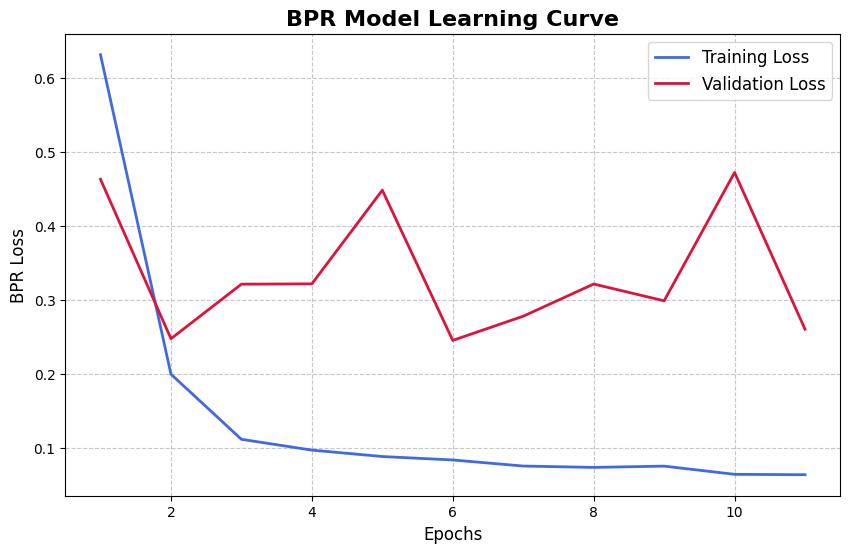

In [15]:
import matplotlib.pyplot as plt

FINAL_EPOCHS = 50
PATIENCE = 5 # Stop if val loss doesn't improve for 5 epochs

print("Initializing final BPR model with best hyperparameters...")
final_model = BPRSessionGRU(
    vocab_size=VOCAB_SIZE,
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"]
).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

scaler = GradScaler('cuda')

# Tracking variables for the graph and early stopping
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print(f"Starting final training on {device} (Max Epochs: {FINAL_EPOCHS}, Early Stopping Patience: {PATIENCE})...")

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    total_train_loss = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{FINAL_EPOCHS} [Train]", leave=False)

    for batch_idx, (x, pos_y, neg_y, mask) in enumerate(train_pbar):
        x, pos_y, neg_y, mask = x.to(device), pos_y.to(device), neg_y.to(device), mask.to(device)
        final_optimizer.zero_grad()

        with autocast('cuda'):
            pos_scores, neg_scores = final_model(x, pos_y, neg_y)
            loss = bpr_loss(pos_scores, neg_scores, mask)

        scaler.scale(loss).backward()
        scaler.step(final_optimizer)
        scaler.update()

        total_train_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())

        if batch_idx % 100 == 0:
            torch.cuda.empty_cache()
            gc.collect()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Loop
    final_model.eval()
    total_val_loss = 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{FINAL_EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for x, pos_y, neg_y, mask in val_pbar:
            x, pos_y, neg_y, mask = x.to(device), pos_y.to(device), neg_y.to(device), mask.to(device)

            with autocast('cuda'):
                pos_scores, neg_scores = final_model(x, pos_y, neg_y)
                loss = bpr_loss(pos_scores, neg_scores, mask)

            total_val_loss += loss.item()
            val_pbar.set_postfix(loss=loss.item())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    torch.cuda.empty_cache()
    gc.collect()

    print(f"Epoch {epoch+1}/{FINAL_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the absolute best weights so far
        os.makedirs("models", exist_ok=True)
        torch.save(final_model.state_dict(), "models/session_gru_bpr_best.pth")
        print("  -> Validation loss improved! Model saved.")
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("\n🚨 Early Stopping Triggered! Model has stopped improving.")
            break

print("\nTraining Complete! Best model saved to models/session_gru_bpr_best.pth")

# --- PLOT THE LEARNING CURVE ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='royalblue', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color='crimson', linewidth=2)
plt.title('BPR Model Learning Curve', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('BPR Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()